In [47]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [48]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [49]:
df = pd.read_csv("../scripts/ga_benchmark_results.csv")
df["success_int"] = df["success"].astype(int)

In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   seed             1800 non-null   int64  
 1   puzzle           1800 non-null   str    
 2   n_gen            1800 non-null   int64  
 3   n_evals          1800 non-null   int64  
 4   success          1800 non-null   bool   
 5   time             1800 non-null   float64
 6   unique_f_in_pop  1800 non-null   int64  
 7   min_f            1800 non-null   int64  
 8   mean_f           1800 non-null   float64
 9   median_f         1800 non-null   float64
 10  max_f            1800 non-null   int64  
 11  greedier         1800 non-null   bool   
 12  exhaustive       1800 non-null   bool   
 13  strict           1800 non-null   bool   
 14  nudge            1800 non-null   bool   
 15  force_unique     1800 non-null   bool   
 16  variant          1800 non-null   str    
 17  variant_type     1600 non

In [51]:
df.groupby(['puzzle'])
def extract_type(row):
    if pd.isna(row['variant_type']):
        if 'modified' in str(row['variant']): return 'modified'
        if 'paper' in str(row['variant']): return 'paper'
    return row['variant_type']

df['variant_type'] = df.apply(extract_type, axis=1)

In [52]:
summary = (
    df.groupby(["puzzle", "variant_type"], dropna=False)
    .agg(
        success_rate=("success", "mean"),
        success_count=("success_int", "sum"),
        # Only report mean for successful runs
        mean_gen_success=("n_gen", lambda x: x[df.loc[x.index, "success"]].mean()),
        max_gen_success=("n_gen", lambda x: x[df.loc[x.index, "success"]].max()),
        mean_best_f=("min_f", "mean"),
        pop_diversity=("unique_f_in_pop", "mean"),
        avg_time=("time", "mean"),
    )
    .reset_index()
)

In [53]:
summary

,puzzle,variant_type,success_rate,success_count,mean_gen_success,max_gen_success,mean_best_f,pop_diversity,avg_time
0,easy-1,modified,1.00,100,4.810000,7.0,0.00,12.91,0.553598
1,easy-1,paper,1.00,100,17.300000,179.0,0.00,6.76,2.217975
2,easy-11,modified,1.00,100,6.370000,10.0,0.00,12.01,0.615555
3,easy-11,paper,0.63,63,295.317460,1869.0,1.58,4.74,108.636034
4,hard-106,modified,0.24,24,516.083333,1679.0,1.52,10.17,210.854124
5,hard-106,paper,0.00,0,NaN,NaN,3.41,3.13,250.941423
6,hard-77,modified,0.92,92,227.576087,1840.0,0.16,10.90,47.031182
7,hard-77,paper,0.02,2,61.000000,82.0,2.85,3.22,244.448391
8,medium-27,modified,1.00,100,10.790000,25.0,0.00,11.47,1.149998
9,medium-27,paper,0.22,22,312.318182,1996.0,2.03,3.40,186.386603


In [54]:
summary["success_rate"] = (summary["success_rate"] * 100).round(1).astype(str) + "%"
summary = summary.sort_values(["puzzle", "success_count"], ascending=[True, False])

print(
    summary[
        ["puzzle", "variant_type", "success_count", "success_rate", "mean_gen_success"]
    ]
)

       puzzle variant_type  success_count success_rate  mean_gen_success
0      easy-1     modified            100       100.0%          4.810000
1      easy-1        paper            100       100.0%         17.300000
2     easy-11     modified            100       100.0%          6.370000
3     easy-11        paper             63        63.0%        295.317460
4    hard-106     modified             24        24.0%        516.083333
5    hard-106        paper              0         0.0%               NaN
6     hard-77     modified             92        92.0%        227.576087
7     hard-77        paper              2         2.0%         61.000000
8   medium-27     modified            100       100.0%         10.790000
9   medium-27        paper             22        22.0%        312.318182
10  medium-29     modified            100       100.0%         30.280000
11  medium-29        paper             15        15.0%        318.200000
12        sd1     modified             33        33

In [55]:
suppl_df = pd.read_csv("../scripts/ga_supplement_benchmark_results.csv")

In [56]:
suppl_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1900 entries, 0 to 1899
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   seed             1900 non-null   int64  
 1   puzzle           1900 non-null   str    
 2   n_gen            1900 non-null   int64  
 3   n_evals          1900 non-null   int64  
 4   success          1900 non-null   bool   
 5   time             1900 non-null   float64
 6   unique_f_in_pop  1900 non-null   int64  
 7   min_f            1900 non-null   int64  
 8   mean_f           1900 non-null   float64
 9   median_f         1900 non-null   float64
 10  max_f            1900 non-null   int64  
 11  greedier         1900 non-null   bool   
 12  exhaustive       1900 non-null   bool   
 13  strict           1900 non-null   bool   
 14  nudge            1900 non-null   bool   
 15  force_unique     1900 non-null   bool   
 16  source           1900 non-null   str    
 17  difficulty       1900 non

In [57]:
websudoku_stats = (
    suppl_df[suppl_df["source"] == "websudoku"]
    .groupby("difficulty")
    .agg(
        success_rate=("success", "mean"),
        avg_gens=("n_gen", lambda x: x[suppl_df.loc[x.index, "success"]].mean()),
        std_gens=("n_gen", lambda x: x[suppl_df.loc[x.index, "success"]].std()),
        mean_min=("min_f", "mean"),
    )
    .reindex(["easy", "medium", "hard", "evil"])
)

In [58]:
# 1. Pre-calculate the Best-case (Min) and Worst-case (Max) per puzzle
puzzle_stats = (
    suppl_df[(suppl_df["source"] == "websudoku") & (suppl_df["success"] == True)]
    .groupby(["difficulty", "puzzle"])["n_gen"]
    .agg(["min", "max"])
    .reset_index()
)

# 2. Average those per difficulty
level_averages = puzzle_stats.groupby("difficulty").agg(
    avg_min_gens=("min", "mean"),
    avg_max_gens=("max", "mean")
)

# 3. Main aggregation
websudoku_stats = (
    suppl_df[suppl_df["source"] == "websudoku"]
    .groupby("difficulty")
    .agg(
        success_rate=("success", "mean"),
        avg_gens=("n_gen", lambda x: x[suppl_df.loc[x.index, "success"]].mean()),
        std_gens=("n_gen", lambda x: x[suppl_df.loc[x.index, "success"]].std()),
        absolute_max=("n_gen", lambda x: x[suppl_df.loc[x.index, "success"]].max()),
    )
    .reindex(["easy", "medium", "hard", "evil"])
)

# 4. Join the puzzle-level metrics
websudoku_stats = websudoku_stats.join(level_averages)

In [59]:
websudoku_stats

,success_rate,avg_gens,std_gens,absolute_max,avg_min_gens,avg_max_gens
difficulty,,,,,,
easy,1.000000,6.166667,1.653684,15,4.700000,8.133333
medium,0.983333,29.315254,96.570120,1116,6.800000,138.733333
hard,0.760000,81.447368,127.955120,748,14.758621,277.103448
evil,0.683333,162.336585,302.577342,1465,25.285714,686.142857


In [60]:
se_stats = (
    suppl_df[suppl_df["source"] == "sudoku_explainer"]
    .groupby("difficulty")
    .agg(
        success_rate=("success", "mean"),
        avg_gens=("n_gen", lambda x: x[suppl_df.loc[x.index, "success"]].mean()),
        std_gens=("n_gen", lambda x: x[suppl_df.loc[x.index, "success"]].std()),
        max_gens=("n_gen", lambda x: x[suppl_df.loc[x.index, "success"]].max()),
        mean_min=("min_f", "mean"),
    )
    .reindex(["easy", "medium", "hard", "superior", "fiendish", "super", "advance"])
)

In [61]:
se_stats

,success_rate,avg_gens,std_gens,max_gens,mean_min
difficulty,,,,,
easy,0.87,89.103448,262.344485,1331,0.26
medium,0.77,157.441558,279.327317,1425,0.46
hard,0.87,77.712644,143.922937,704,0.27
superior,0.67,112.313433,172.833622,740,0.66
fiendish,0.69,179.231884,316.300497,1330,0.62
super,0.70,105.857143,240.409812,1107,0.60
advance,0.80,141.525000,219.433100,896,0.40


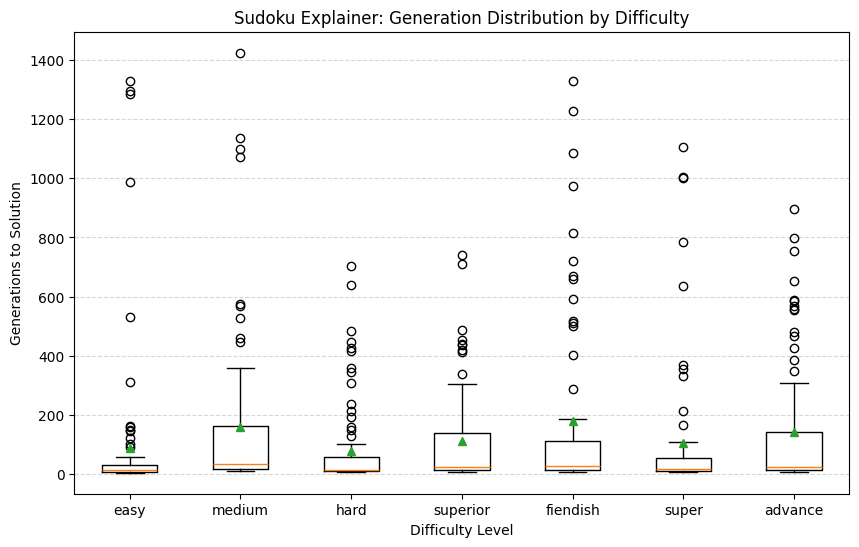

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
%matplotlib inline

se_only = suppl_df[
    (suppl_df["source"] == "sudoku_explainer") &
    (suppl_df["success"] == True)
].copy()

level_order = ["easy", "medium", "hard", "superior", "fiendish", "super", "advance"]

plot_data = [
    se_only[se_only["difficulty"] == lvl]["n_gen"] for lvl in level_order
]

plt.boxplot(plot_data, tick_labels=level_order, showmeans=True)

plt.title("Sudoku Explainer: Generation Distribution by Difficulty", fontsize=12)
plt.ylabel("Generations to Solution")
plt.xlabel("Difficulty Level")
plt.grid(axis="y", linestyle="--", alpha=0.5)
# plt.yscale("log")
plt.show()

In [63]:
se_df = suppl_df[suppl_df["source"] == "sudoku_explainer"].copy()
table_v = (
    se_df.groupby(["difficulty", "puzzle"])
    .agg(
        success_rate=("success", "mean"),
        avg_gen=("n_gen", lambda x: x[se_df.loc[x.index, "success"]].mean()),
    )
    .reset_index()
)
diff_order = {
    "easy": 0,
    "medium": 1,
    "hard": 2,
    "superior": 3,
    "fiendish": 4,
    "super": 5,
    "advance": 6,
}
table_v["order"] = table_v["difficulty"].map(diff_order)
table_v = table_v.sort_values(["order", "puzzle"]).drop(columns=["order"])
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(table_v)

,difficulty,puzzle,success_rate,avg_gen
10,easy,easy-no.1,1.0,7.300000
11,easy,easy-no.10,0.7,96.714286
12,easy,easy-no.2,1.0,15.500000
13,easy,easy-no.3,1.0,7.200000
14,easy,easy-no.4,1.0,10.900000
15,easy,easy-no.5,0.9,173.111111
16,easy,easy-no.6,0.6,298.666667
17,easy,easy-no.7,1.0,4.800000
18,easy,easy-no.8,0.5,333.600000
19,easy,easy-no.9,1.0,160.000000


In [64]:
# puzzle_audit = suppl_df[suppl_df['difficulty'].isin(['easy', 'medium'])].groupby(['difficulty', 'puzzle']).agg(
puzzle_audit = (
    suppl_df.groupby(["difficulty", "puzzle"])
    .agg(
        success_count=("success", "sum"),
        min_f_reached=("min_f", "min"),
        avg_f_reached=("min_f", "mean"),
    )
    .reset_index()
)

failed_puzzles = puzzle_audit[puzzle_audit["success_count"] < 10]
display(failed_puzzles)

,difficulty,puzzle,success_count,min_f_reached,avg_f_reached
0,advance,advance-no.1,6,0,0.8
1,advance,advance-no.10,8,0,0.4
2,advance,advance-no.2,9,0,0.2
4,advance,advance-no.4,5,0,1.0
5,advance,advance-no.5,7,0,0.6
...,...,...,...,...,...
182,superior,superior-no.2,8,0,0.4
183,superior,superior-no.3,4,0,1.2
184,superior,superior-no.4,4,0,1.2
185,superior,superior-no.5,4,0,1.2


In [65]:
# rewrite_df = pd.read_csv("../scripts/ga_supplement_benchmark_results.csv")
# targets = [
#     "easy-no.10",
#     "easy-no.5",
#     "easy-no.6",
#     "easy-no.8",
#     "easy-no.9",
#     "1195098050",
#     "1490459242",
#     "2152823431",
#     "2372227873",
#     "medium-no.1",
#     "medium-no.2",
#     "medium-no.3",
#     "medium-no.4",
#     "medium-no.5",
#     "medium-no.6",
#     "medium-no.8",
# ]
# df_cleaned = rewrite_df[~rewrite_df["puzzle"].isin(targets)]
# df_cleaned.to_csv("../scripts/ga_supplement_benchmark_results.csv", index=False)